# IPL Bowling Analysis
Examining wicket-taking, economy, pressure bowling, and phase-wise performance
using ball-by-ball data (2008–2024).

## 1. Setup

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.magics import display

delivery = pd.read_csv('Resources/deliveries.csv')
merged = pd.read_csv('Resources/merged_data.csv')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Top Wicket-Takers (All Time)

Taking wickets is one of the primary responsibilities of a bowler in T20 cricket. However, not every dismissal is credited to the bowler. Run outs and other non-bowling dismissals are excluded to accurately identify the IPL's leading wicket-takers.

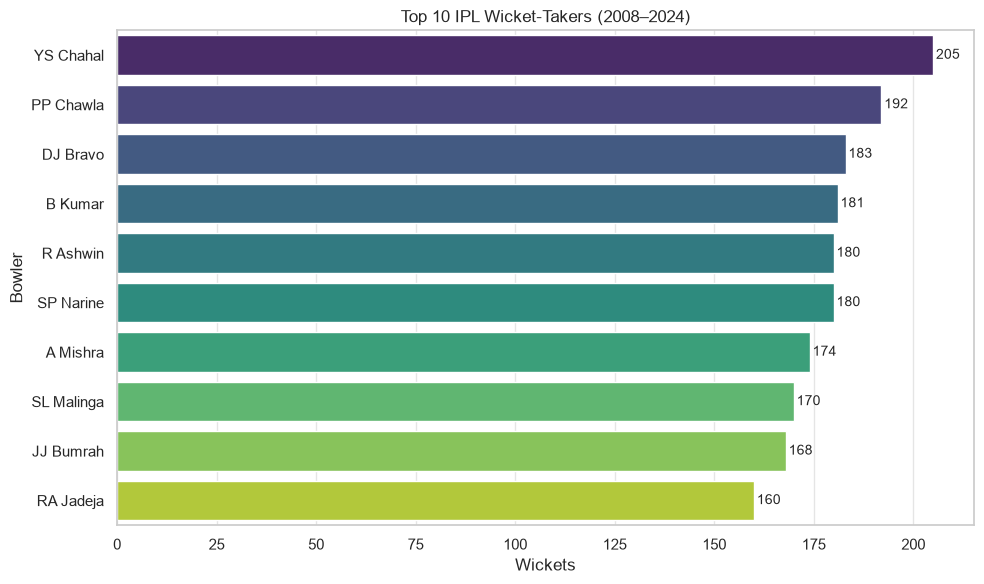

In [9]:
#Dismissals that are not credited to the bowler
non_bowler_dismissals = ['run out', 'retired hurt', 'obstructing the field', 'retired out']

#Filter wickets credited to the bowler
wickets_data = delivery[(delivery['is_wicket'] == 1) & (~delivery['dismissal_kind'].isin(non_bowler_dismissals))]
top_wickets = (wickets_data.groupby('bowler').size().sort_values(ascending=False).head(10))
top_wickets

#Visualisation
plt.figure(figsize=(10, 6))

ax = sns.barplot(x=top_wickets.values,y=top_wickets.index,palette="viridis", hue = top_wickets.index)
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=2)

plt.title("Top 10 IPL Wicket-Takers (2008–2024)")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.tight_layout()
plt.savefig("charts/top_wicket_takers.png", dpi=300)
plt.savefig("charts/top_wicket_takers.png")
plt.show()

### Observations

- **YS Chahal** leads the all-time wicket charts with **205 wickets**, followed by **PP Chawla** and **DJ Bravo**.
- The gap between the top few bowlers highlights the value of both longevity and sustained wicket-taking ability across multiple IPL seasons.
- Several bowlers in the top 10 have represented multiple franchises, reflecting long and successful IPL careers.

## 3. Best Economy Rates (Minimum 1000 Legal Deliveries)

Taking wickets is important, but preventing runs is equally valuable in T20 cricket. Economy rate measures the average number of runs conceded per over. To ensure a fair comparison, only bowlers who have delivered at least 500 legal balls are included.

Note: The dataset abbreviates player names. The entry "R Sharma" represents multiple players and was excluded from bowling analyses to avoid merging statistics from different bowlers.

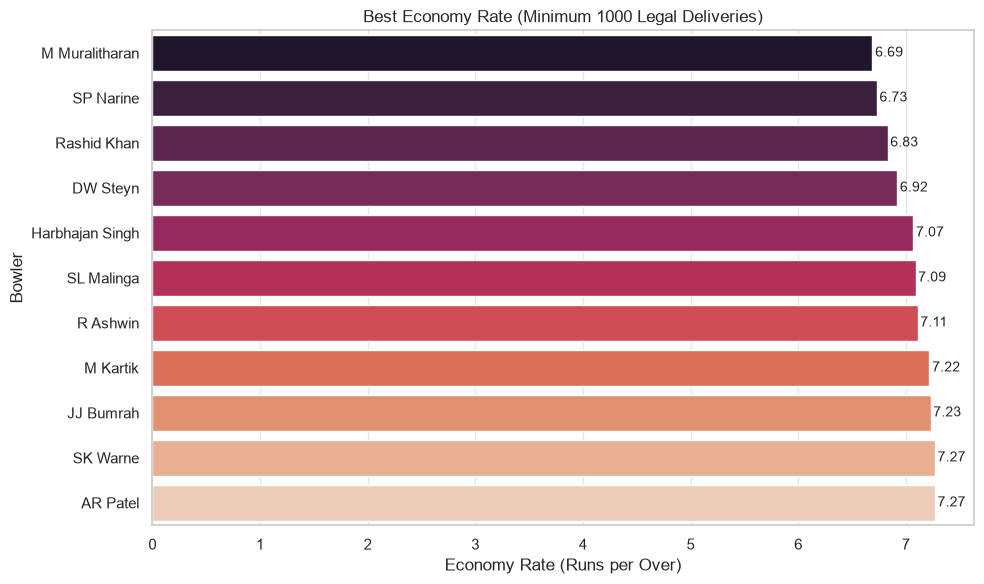

In [10]:
#Legal deliveries(excluding wides)
legal_deliveries = delivery[delivery['extras_type'] != 'wides']

# Legal balls bowled
balls_bowled = (legal_deliveries.groupby('bowler').size())

# Runs conceded by the bowler
delivery['bowler_runs'] = delivery['batsman_runs']

delivery.loc[delivery['extras_type'].isin(['wides', 'noballs']),'bowler_runs']\
    += delivery.loc[delivery['extras_type'].isin(['wides','noballs']),'extra_runs']

runs_conceded = delivery.groupby('bowler')['bowler_runs'].sum()

# Economy
economy = (runs_conceded / balls_bowled * 6).round(2)
MIN_BALLS = 1000
qualified_economy = (economy[balls_bowled >= MIN_BALLS].sort_values().head(11))
qualified_economy = qualified_economy.drop('R Sharma', errors='ignore') # Dropping the name R Sharma
#display(qualified_economy.to_frame(name="Economy"))

#Visualisation
plt.figure(figsize=(10,6))

ax = sns.barplot(x=qualified_economy.values,y=qualified_economy.index,palette="rocket", hue = qualified_economy.index)
for container in ax.containers:\
    ax.bar_label(container, fontsize=10, padding=2)

plt.title("Best Economy Rate (Minimum 1000 Legal Deliveries)")
plt.xlabel("Economy Rate (Runs per Over)")
plt.ylabel("Bowler")

plt.tight_layout()
plt.savefig("charts/economy_rate.png", dpi=300)
plt.show()

### Observations

- **M Murlitharan** has the best economy rate at **6.69 runs per over**, making him the most economical bowler among those with substantial IPL experience.
- Economy-focused bowlers are not always the highest wicket-takers, highlighting the trade-off between containing runs and attacking for wickets.
- Several spinners feature prominently, reflecting their effectiveness in restricting scoring during the middle overs.

## 4. Highest Dot Ball Percentage (Minimum 1000 Legal Deliveries)

Dot balls build pressure by preventing the batting side from scoring. While wicket-taking and economy rate measure different aspects of bowling, dot-ball percentage highlights bowlers who consistently restrict scoring opportunities.

To ensure a fair comparison, only bowlers with at least 1000 legal deliveries are included.

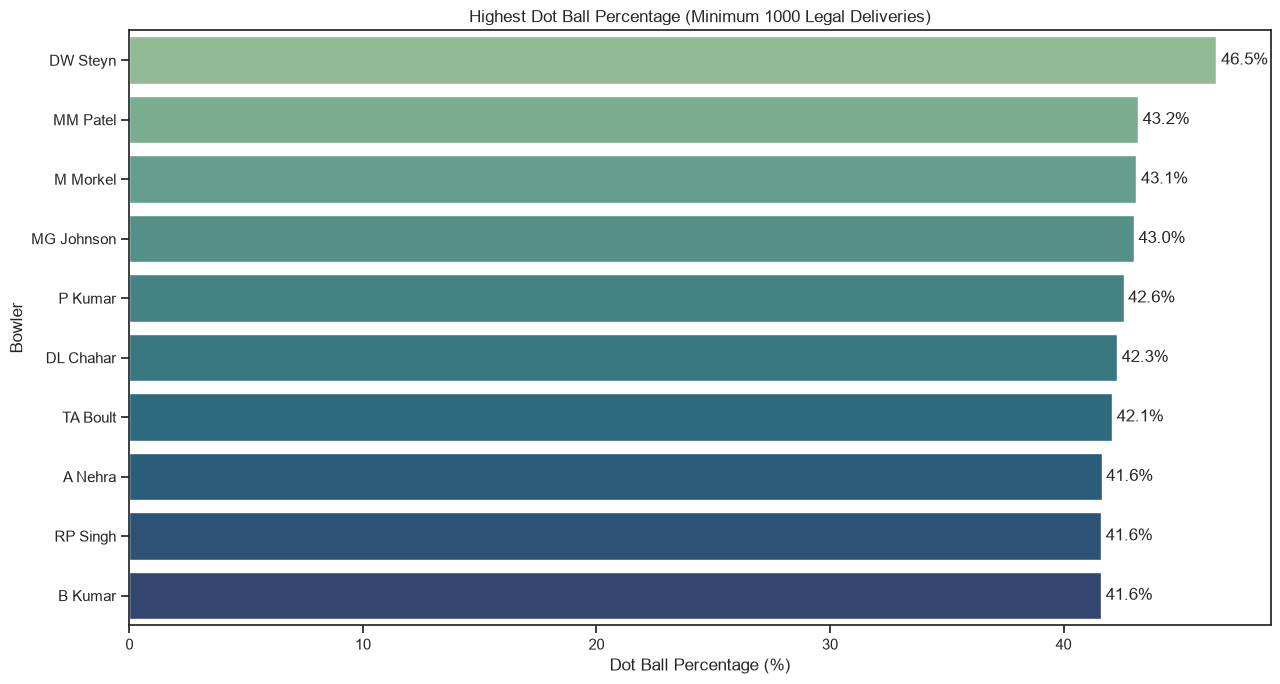

In [11]:
#Dot balls(legal deliveries with zero runs scored)
dot_balls = legal_deliveries[legal_deliveries["total_runs"] == 0]

#Dot ball count
dot_ball_count = dot_balls.groupby("bowler").size()

# Dot ball percentage
dot_ball_percentage = (dot_ball_count / balls_bowled * 100).round(2)

MIN_BALLS = 1000
qualified_dot_pct = (dot_ball_percentage[balls_bowled >= MIN_BALLS]
    .drop('R Sharma', errors='ignore').sort_values(ascending=False).head(10))
#display(qualified_dot_pct.to_frame(name='Dot Ball %'))

#Visualisation
plt.figure(figsize=(13,7))
sns.set_style("ticks")
sns.barplot(x=qualified_dot_pct.values,y=qualified_dot_pct.index,palette='crest', hue = qualified_dot_pct.index)

for i, value in enumerate(qualified_dot_pct.values):
    plt.text(
        value + 0.2,
        i,
        f'{value:.1f}%',
        va='center'
    )

plt.title('Highest Dot Ball Percentage (Minimum 1000 Legal Deliveries)')
plt.xlabel('Dot Ball Percentage (%)')
plt.ylabel('Bowler')

plt.tight_layout()
plt.savefig('charts/dot_ball_percentage.png', dpi=300)
plt.show()

### Observations

- **DW Steyn** has the highest dot-ball percentage at **46.5%**, meaning nearly half the balls he bowled were dot balls.
- Most bowlers with high dot-ball percentages also rank among the most economical, highlighting the strong relationship between pressure bowling and economy rate.
- Some bowlers generate pressure through dot balls even without being among the leading wicket-takers, demonstrating that restricting runs is valuable in its own right.

## 5. Best Bowling Average (Minimum 20 Wickets)

Bowling average measures the number of runs conceded for every wicket taken. Unlike economy rate, which focuses on restricting runs, bowling average reflects how costly each wicket is.

Only bowlers with at least **20 wickets** are included.

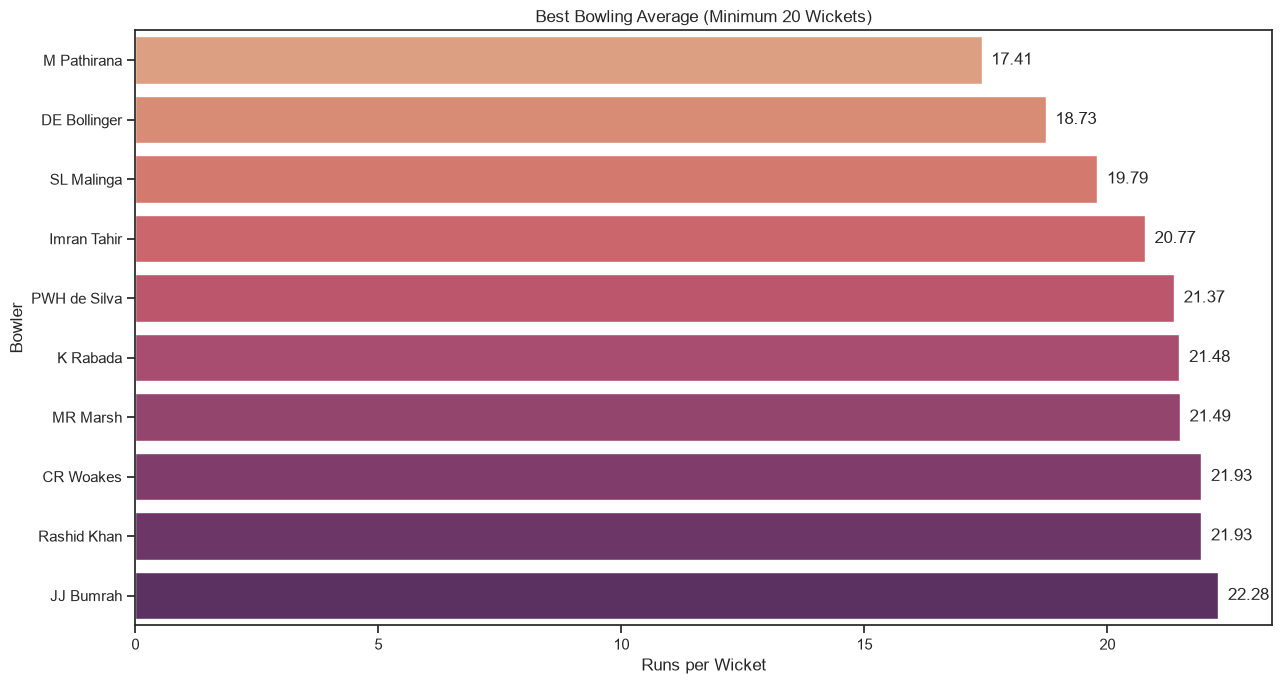

In [12]:
# Wickets credited to the bowler
bowler_wickets = (wickets_data.groupby('bowler').size())

bowling_average = (runs_conceded / bowler_wickets).round(2)

MIN_WICKETS = 30

qualified_average = (
    bowling_average.loc[bowler_wickets[bowler_wickets >= MIN_WICKETS].index]
    .drop('R Sharma', errors='ignore').sort_values().head(10))

#Visualisation
plt.figure(figsize=(13,7))

sns.barplot(x=qualified_average.values,y=qualified_average.index,palette='flare', hue = qualified_average.index)

for i, value in enumerate(qualified_average.values):plt.text(value + 0.2,i,f'{value:.2f}',va='center')

plt.title('Best Bowling Average (Minimum 20 Wickets)')
plt.xlabel('Runs per Wicket')
plt.ylabel('Bowler')

plt.tight_layout()
plt.savefig('charts/bowling_average.png', dpi=300)
plt.show()

## 6. Types of Dismissals

Different bowlers dismiss batters in different ways. This analysis shows the distribution of dismissal types that have happened, providing insight into the most common methods of taking wickets in the IPL.

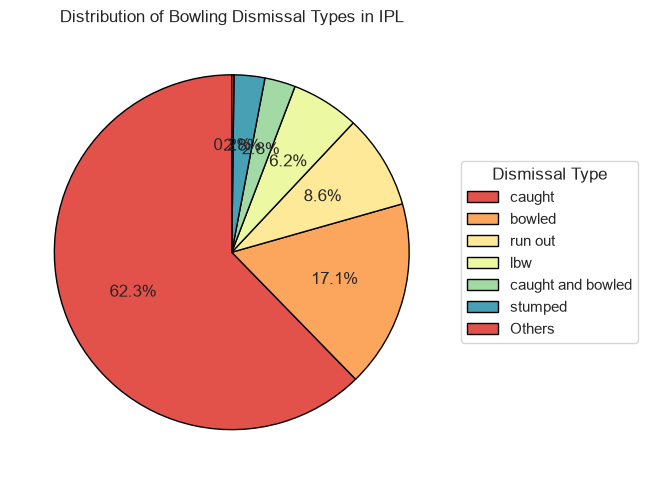

In [13]:

dismissal_counts = delivery['dismissal_kind'].value_counts()
dismissal_percentage = (dismissal_counts / dismissal_counts.sum() * 100).round(1)

# Categories contributing less than 1%
threshold = 1
others = dismissal_percentage[dismissal_percentage < threshold].sum()
dismissal_percentage = dismissal_percentage[dismissal_percentage >= threshold]
dismissal_percentage['Others'] = others
dismissal_percentage = dismissal_percentage.round(1)
'''dismissal_percentage'''
#Visualisation
colors = sns.color_palette('Spectral')[0:len(dismissal_percentage)]
plt.pie(dismissal_percentage,autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor': 'black'}, colors=colors)

plt.legend(
    dismissal_percentage.index,title="Dismissal Type",
    loc="center left",bbox_to_anchor=(1, 0.5))

plt.title('Distribution of Bowling Dismissal Types in IPL')

plt.tight_layout()
plt.savefig('charts/dismissal_types_pie.png', dpi=300)
plt.show()

## 7. Powerplay vs Death Overs Economy

Bowling conditions vary significantly across different phases of a T20 innings. The Powerplay (overs 1-6) allows only two fielders outside the 30-yard circle, encouraging aggressive batting. The Death Overs (overs 17-20) are equally demanding, with batters attempting to maximize scoring in the final overs.

This analysis compares bowlers' economy rates in these two phases to identify specialists who consistently restrict runs under pressure.

Only bowlers who have delivered at least **200 legal balls** in a phase are included.

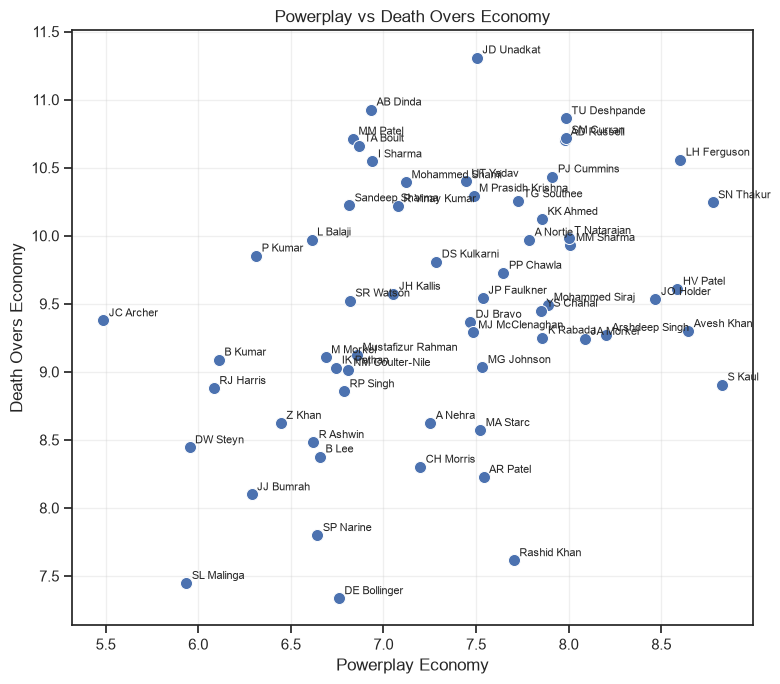

In [14]:
# Powerplay (Overs 1-6)
powerplay = delivery[(delivery['over'] <= 5) &(delivery['extras_type'] != 'wides')
                     &(delivery['bowler'] != 'R Sharma')].copy()

# Death Overs (Overs 17-20)
death = delivery[(delivery['over'] >= 16) &(delivery['extras_type'] != 'wides')
                 &(delivery['bowler'] != 'R Sharma')].copy()

#Runs conceded
for df in [powerplay, death]:
    df['bowler_runs'] = df['batsman_runs']
    mask = df['extras_type'].isin(['wides', 'noballs'])
    df.loc[mask, 'bowler_runs'] += df.loc[mask, 'extra_runs']

#Economy calculation
# Powerplay
pp_runs = powerplay.groupby('bowler')['bowler_runs'].sum()
pp_balls = powerplay.groupby('bowler').size()
pp_economy = (pp_runs / pp_balls * 6)

# Death
death_runs = death.groupby('bowler')['bowler_runs'].sum()
death_balls = death.groupby('bowler').size()
death_economy = (death_runs / death_balls * 6)

#Qualification & Combine
MIN_BALLS = 200

pp_economy = pp_economy[pp_balls >= MIN_BALLS]
death_economy = death_economy[death_balls >= MIN_BALLS]

phase_comparison = pd.DataFrame({
    'Powerplay Economy': pp_economy,
    'Death Economy': death_economy
}).dropna()
'''phase_comparison = phase_comparison.head(30).sort_values(["Death Economy", "Powerplay Economy"])
display(phase_comparison)'''
#----------------------------------------------------------------------------------------------------------------------------
#Visualisation


plt.figure(figsize=(8,7))
sns.scatterplot(data=phase_comparison,x='Powerplay Economy',y='Death Economy',s=75)

# Label each point
for bowler, row in phase_comparison.iterrows():
    plt.text(row['Powerplay Economy'] + 0.03,row['Death Economy'] + 0.03,bowler,fontsize=8)

plt.xlabel('Powerplay Economy')
plt.ylabel('Death Overs Economy')
plt.title('Powerplay vs Death Overs Economy')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('charts/powerplay_vs_death.png', dpi=300)
plt.show()

### Observations

- Bowlers near the **bottom-left** perform well in both phases, indicating excellent control throughout the innings.
- Most bowlers concede runs at a higher rate during the death overs because of aggressive batting.
- Some bowlers specialize in the Powerplay, while others are more effective at the death, reflecting different bowling roles within a team.

# Key Findings

This analysis explored multiple aspects of bowling performance in the Indian Premier League (IPL), including wicket-taking ability, economy rate, dot-ball percentage, dismissal patterns, and phase-wise economy.

### Major Findings

- Bowlers with the highest wicket counts were generally those who enjoyed long and consistent IPL careers.
- Economy rate highlighted bowlers who consistently restricted scoring while meeting a minimum workload threshold.
- Dot-ball percentage showed a strong relationship with economy rate, indicating that bowlers who frequently delivered dot balls were often among the most economical.
- **Caught** was by far the most common mode of dismissal, followed by **bowled** and **LBW**, reflecting the dominant ways bowlers dismiss batters in T20 cricket.
- Phase-wise analysis showed that most bowlers concede runs at a higher rate during the death overs than during the Powerplay because of the aggressive batting approach in the final overs.

### Conclusion

No single metric fully defines a great bowler. Wickets measure attacking ability, economy reflects run prevention, dot-ball percentage captures pressure-building, and phase-wise economy reveals how bowlers perform under different match situations. Combining these metrics provides a more comprehensive evaluation of bowling performance in the IPL.

> **Dataset Note:** The dataset stores player names in abbreviated form. The bowler **"R Sharma"** was excluded from bowling analyses because the abbreviation represents multiple players, which could otherwise merge their statistics and produce misleading results.